# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Jaya Jaya Institute


- Nama:Ahmad Rizhan
- Email:rizhan25@gmail.com
- Id Dicoding:ahmad_rizhan

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model
from sklearn.ensemble import RandomForestClassifier

### Menyiapkan data yang akan diguankan

## Data Understanding

In [2]:
df = pd.read_csv('data.csv', sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# Melihat ukuran dataset
print("Shape data:", df.shape)

# Informasi tipe data
df.info()

Shape data: (4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                   

In [4]:
# Cek missing values
df.isnull().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
# Statistik deskriptif
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


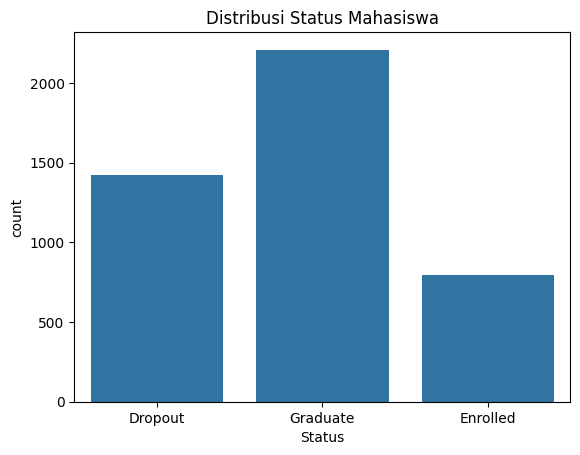

In [7]:
# Distribusi target
df['Status'].value_counts()

# Visualisasi
sns.countplot(x='Status', data=df)
plt.title('Distribusi Status Mahasiswa')
plt.show()

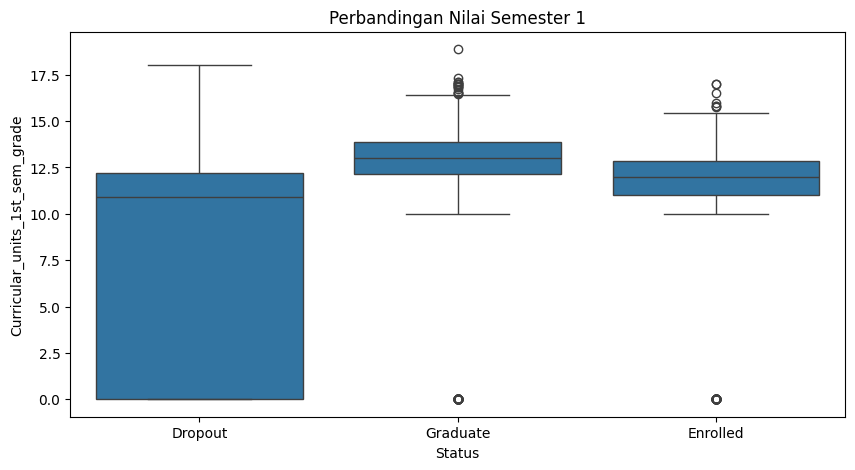

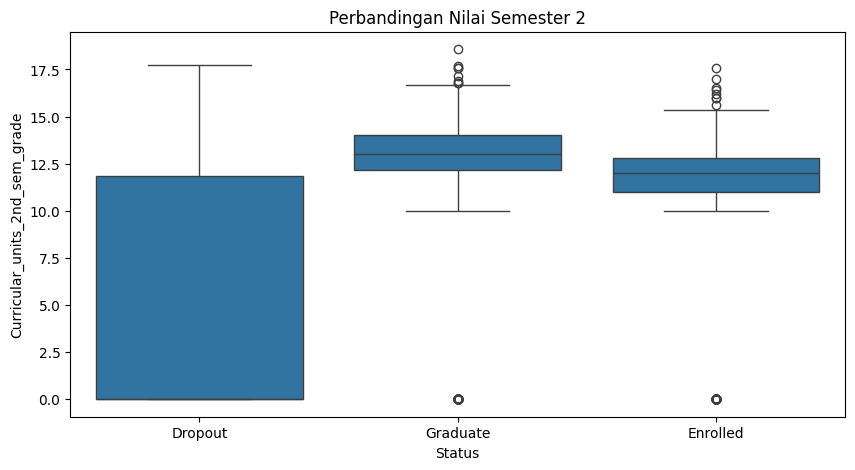

In [8]:
# Rata-rata nilai berdasarkan status
df.groupby('Status')['Curricular_units_1st_sem_grade'].mean()
df.groupby('Status')['Curricular_units_2nd_sem_grade'].mean()

# Visualisasi
plt.figure(figsize=(10,5))
sns.boxplot(x='Status', y='Curricular_units_1st_sem_grade', data=df)
plt.title('Perbandingan Nilai Semester 1')
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_grade', data=df)
plt.title('Perbandingan Nilai Semester 2')
plt.show()

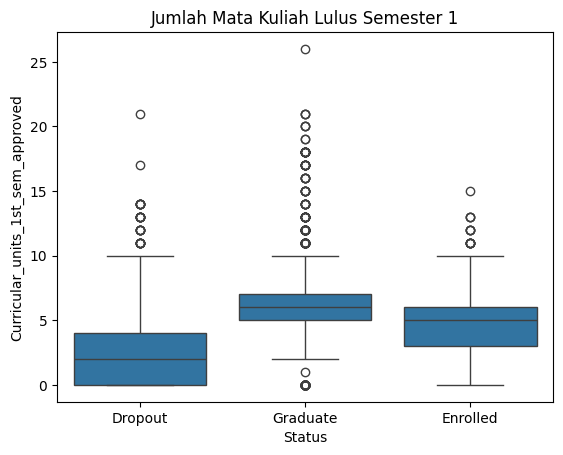

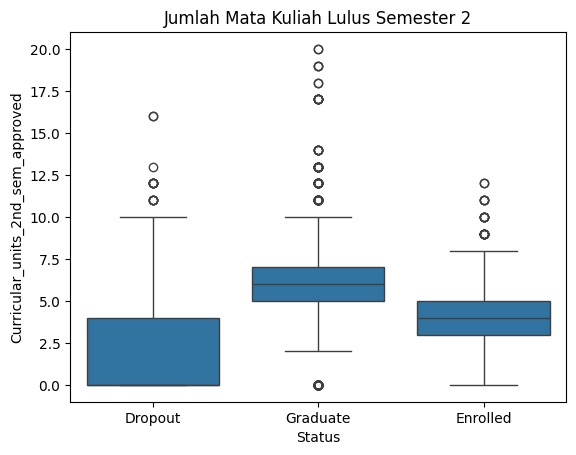

In [9]:
sns.boxplot(x='Status', y='Curricular_units_1st_sem_approved', data=df)
plt.title('Jumlah Mata Kuliah Lulus Semester 1')
plt.show()

sns.boxplot(x='Status', y='Curricular_units_2nd_sem_approved', data=df)
plt.title('Jumlah Mata Kuliah Lulus Semester 2')
plt.show()

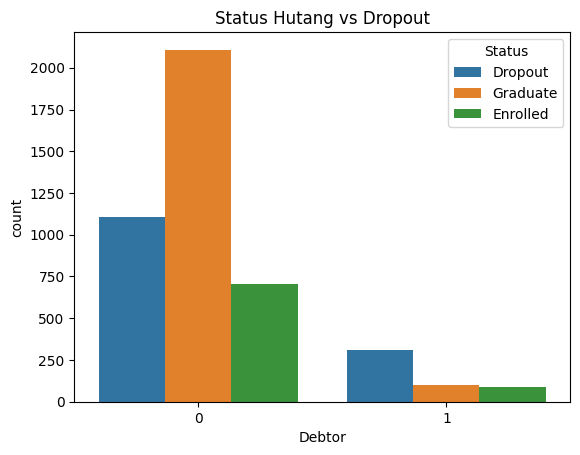

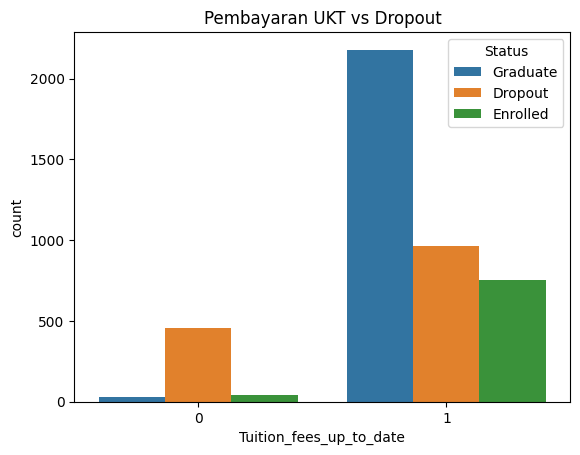

In [10]:
sns.countplot(x='Debtor', hue='Status', data=df)
plt.title('Status Hutang vs Dropout')
plt.show()

sns.countplot(x='Tuition_fees_up_to_date', hue='Status', data=df)
plt.title('Pembayaran UKT vs Dropout')
plt.show()

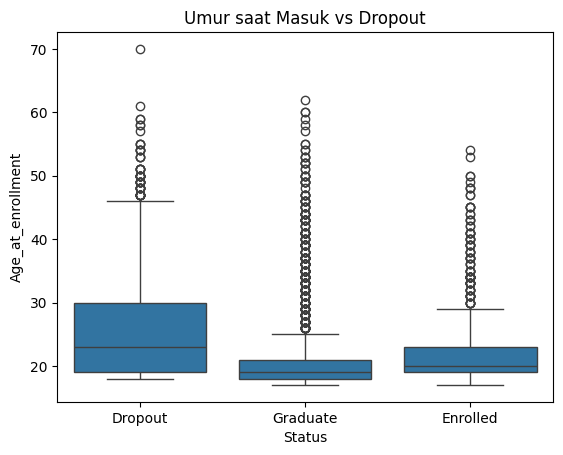

In [11]:
sns.boxplot(x='Status', y='Age_at_enrollment', data=df)
plt.title('Umur saat Masuk vs Dropout')
plt.show()

In [12]:
# Simpan data bersih untuk dashboard
df.to_csv('data_bersih.csv', index=False, sep=';')

## Data Preparation / Preprocessing

In [13]:
# Encode target
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])

df['Status'].value_counts()

,count
Status,
2,2209
0,1421
1,794


In [14]:
X = df.drop('Status', axis=1)
y = df['Status']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Modeling

In [17]:
# Inisialisasi model
model = RandomForestClassifier(random_state=42)

# Training
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [18]:
# Prediksi
y_pred = model.predict(X_test)

## Evaluation

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7638418079096045


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.75      0.77       284
           1       0.56      0.35      0.43       159
           2       0.78      0.92      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885



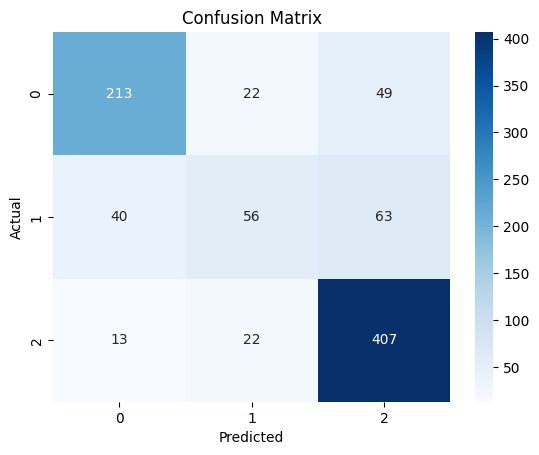

In [21]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
import joblib
joblib.dump(model, 'model.joblib')

['model.joblib']

In [26]:
with open("app.py", "w") as f:
    f.write("""
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load('model.joblib')

st.title("Prediksi Dropout Mahasiswa")

st.write("Masukkan data mahasiswa:")

age = st.number_input("Age at Enrollment", 15, 70, 20)
debtor = st.selectbox("Debtor", [0,1])
tuition = st.selectbox("Tuition Fees Up to Date", [0,1])
grade1 = st.number_input("Nilai Semester 1", 0.0, 20.0, 10.0)
grade2 = st.number_input("Nilai Semester 2", 0.0, 20.0, 10.0)

if st.button("Predict"):
    input_data = pd.DataFrame({
        'Age_at_enrollment': [age],
        'Debtor': [debtor],
        'Tuition_fees_up_to_date': [tuition],
        'Curricular_units_1st_sem_grade': [grade1],
        'Curricular_units_2nd_sem_grade': [grade2]
    })

    prediction = model.predict(input_data)

    if prediction[0] == 1:
        st.success("Mahasiswa berpotensi LULUS")
    else:
        st.error("Mahasiswa berpotensi DROPOUT")
""")

In [24]:
with open("requirements.txt", "w") as f:
    f.write("""
pandas
numpy
scikit-learn
joblib
streamlit
""")

In [25]:
with open("README.md","w") as f:
  f.write("""
# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Jaya Jaya Institute

## Business Understanding
Jaya Jaya Institute merupakan institusi pendidikan yang menghadapi permasalahan dalam pengelolaan mahasiswa, khususnya tingginya tingkat mahasiswa yang tidak menyelesaikan studi (dropout).

Hal ini berdampak pada kualitas pendidikan, reputasi institusi, serta efisiensi operasional. Oleh karena itu, diperlukan analisis berbasis data untuk mengidentifikasi faktor-faktor yang mempengaruhi dropout mahasiswa.

### Permasalahan Bisnis
- Tingginya tingkat dropout mahasiswa
- Kurangnya insight terkait faktor penyebab mahasiswa tidak lulus
- Belum adanya sistem monitoring berbasis data

### Cakupan Proyek
- Analisis data mahasiswa
- Data preprocessing (cleaning, encoding, transformasi)
- Pembuatan model machine learning
- Pembuatan dashboard visualisasi

## Persiapan

### 1. Sumber Data
Dataset dapat diunduh melalui link berikut :
https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/data.csv

### 2. Membuat Virtual Environment (venv)
Jalankan perintah berikut di terminal:

python -m venv venv

### 3. Mengaktifkan Virtual Environment

Windows:
venv\\Scripts\\activate

Mac/Linux:
source venv/bin/activate

### 4. Menginstal Dependencies
Gunakan file requirements.txt agar instalasi lebih konsisten:

pip install -r requirements.txt

### 5. Menjalankan Program
Jalankan file berikut untuk melakukan prediksi:

python app.py

## Business Dashboard
Dashboard dibuat menggunakan Looker Studio untuk memvisualisasikan faktor-faktor yang mempengaruhi dropout mahasiswa.

Dashboard menampilkan:
- Distribusi status mahasiswa (Dropout vs Graduate)
- Perbandingan nilai semester 1 dan 2
- Jumlah mata kuliah lulus
- Pengaruh status hutang (Debtor)
- Pengaruh pembayaran UKT
- Perbandingan umur mahasiswa

Dashboard ini membantu institusi dalam:
- Mengidentifikasi faktor utama penyebab dropout
- Melihat pola dropout berdasarkan berbagai aspek
- Mendukung pengambilan keputusan berbasis data

Link Dashboard:
https://lookerstudio.google.com/reporting/e8cfa546-1cb8-44c7-adca-387ee672d9e1

## Conclusion
Model machine learning telah berhasil dibangun untuk memprediksi kemungkinan mahasiswa mengalami dropout.

### Performa Model
Model Random Forest menunjukkan performa yang cukup baik dalam mengklasifikasikan mahasiswa dropout dan graduate berdasarkan data yang tersedia.

### Insight Utama
- Mahasiswa dengan nilai akademik rendah memiliki risiko dropout lebih tinggi
- Jumlah mata kuliah yang sedikit lulus berhubungan dengan kemungkinan dropout
- Mahasiswa dengan status hutang (debtor) lebih rentan mengalami dropout
- Pembayaran UKT yang tidak lancar meningkatkan risiko dropout
- Faktor umur juga menunjukkan pengaruh terhadap status mahasiswa

### Rekomendasi
- Memberikan bimbingan akademik bagi mahasiswa dengan nilai rendah
- Monitoring jumlah mata kuliah lulus sejak semester awal
- Memberikan bantuan finansial atau skema pembayaran fleksibel
- Menerapkan sistem early warning berbasis data
- Melakukan evaluasi berkala terhadap performa mahasiswa
- Fokus intervensi pada semester awal
  """)